In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from IPython.display import Image, display


Displaying image: apples.jpg


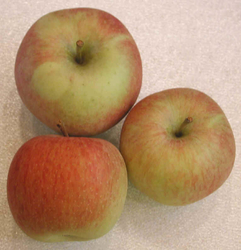


Displaying image: clock.jpg


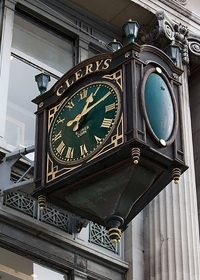


Displaying image: oranges.jpg


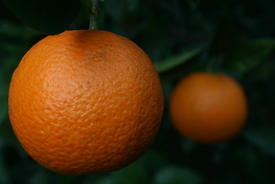


Displaying image: car.jpg


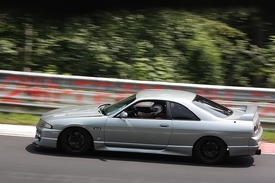

In [2]:
# Some example images
image_files = [
    'apples.jpg',
    'clock.jpg',
    'oranges.jpg',
    'car.jpg'
]

for image_file in image_files:
    print(f"\nDisplaying image: {image_file}")
    display(Image(filename=f"images/{image_file}"))

In [3]:
import sys
print(sys.executable)                                                                                                                                                                                                           
!{sys.executable} -m pip show setuptools

/opt/anaconda3/envs/MLOps-Introduccion-Yolo/bin/python
Name: setuptools
Version: 69.5.1
Summary: Easily download, build, install, upgrade, and uninstall Python packages
Home-page: https://github.com/pypa/setuptools
Author: Python Packaging Authority
Author-email: distutils-sig@python.org
License: 
Location: /opt/anaconda3/envs/MLOps-Introduccion-Yolo/lib/python3.10/site-packages
Requires: 
Required-by: tensorboard, tensorflow


In [4]:
import cv2
import cvlib as cv
from cvlib.object_detection import draw_bbox
import os


def detect_and_draw_box(filename, model="yolov3-tiny", confidence=0.5):
    """Detects common objects on an image and creates a new image with bounding boxes.

    Args:
        filename (str): Filename of the image.
        model (str): Either "yolov3" or "yolov3-tiny". Defaults to "yolov3-tiny".
        confidence (float, optional): Desired confidence level. Defaults to 0.5.
    """

    # Images are stored under the images/ directory
    img_filepath = f'images/{filename}'

    # Read the image into a numpy array
    img = cv2.imread(img_filepath)

    # Check if the image was loaded successfully
    if img is None:
        print(f"Error: Unable to load image at {img_filepath}")
        return

    # Perform the object detection
    bbox, label, conf = cv.detect_common_objects(img, confidence=confidence, model=model)

    # Print current image's filename
    print(f"========================\nImage processed: {filename}\n")

    # Print detected objects with confidence level
    for l, c in zip(label, conf):
        print(f"Detected object: {l} with confidence level of {c}\n")

    # Create a new image that includes the bounding boxes
    output_image = draw_bbox(img, bbox, label, conf)

    # Create the directory if it doesn't exist -------
    if not os.path.exists('images_with_boxes'):
        os.makedirs('images_with_boxes')
    #-------

    # Save the image in the directory images_with_boxes
    cv2.imwrite(f'images_with_boxes/{filename}', output_image)

    # Display the image with bounding boxes
    display(Image(f'images_with_boxes/{filename}'))

Image processed: apples.jpg

Detected object: apple with confidence level of 0.9589300155639648

Detected object: apple with confidence level of 0.9145929217338562

Detected object: orange with confidence level of 0.6645329594612122



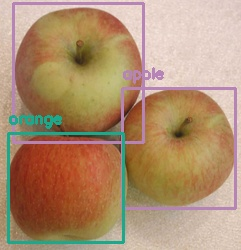

Image processed: clock.jpg

Detected object: clock with confidence level of 0.9683181047439575



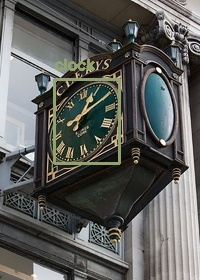

Image processed: oranges.jpg

Detected object: orange with confidence level of 0.618559718132019

Detected object: orange with confidence level of 0.5561692714691162



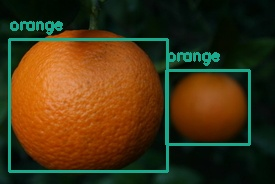

Image processed: car.jpg

Detected object: car with confidence level of 0.6325438022613525



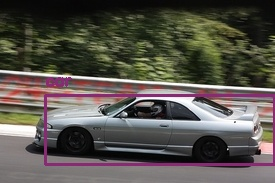

In [5]:
for image_file in image_files:
    detect_and_draw_box(image_file)

Image processed: apples.jpg

Detected object: apple with confidence level of 0.9589300155639648

Detected object: apple with confidence level of 0.9145929217338562



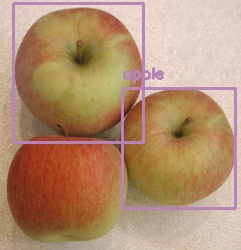

Image processed: clock.jpg

Detected object: clock with confidence level of 0.9683181047439575



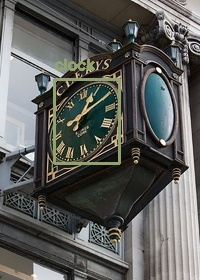

Image processed: oranges.jpg



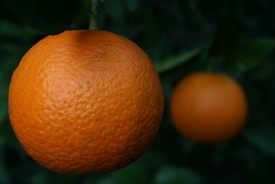

Image processed: car.jpg



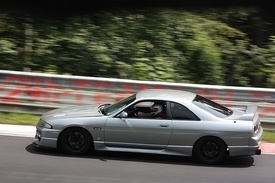

In [6]:
for image_file in image_files:
    detect_and_draw_box(image_file, confidence=0.9)

Image processed: fruits.jpg

Detected object: apple with confidence level of 0.6014094352722168



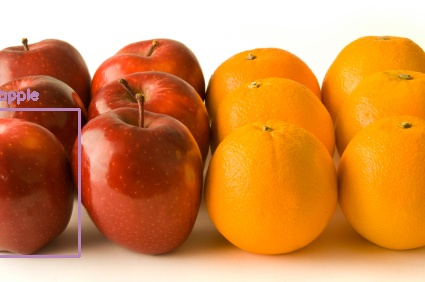

In [7]:
detect_and_draw_box("fruits.jpg")

Image processed: fruits.jpg

Detected object: apple with confidence level of 0.6014094352722168

Detected object: orange with confidence level of 0.3202775716781616

Detected object: orange with confidence level of 0.3168172538280487

Detected object: apple with confidence level of 0.3144986629486084

Detected object: orange with confidence level of 0.30153197050094604



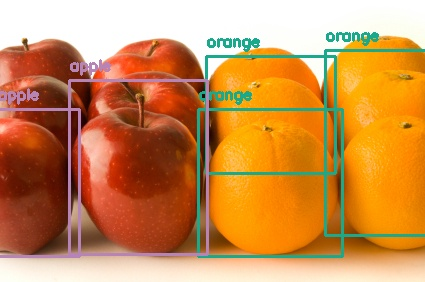

In [8]:
detect_and_draw_box("fruits.jpg", confidence=0.3)

In [9]:
import io
import uvicorn
import numpy as np
import nest_asyncio
from enum import Enum
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import StreamingResponse

In [10]:
# Assign an instance of the FastAPI class to the variable "app".
# You will interact with your api using this instance.
app = FastAPI(title='Deploying un Modelo ML con FastAPI')

# Valores pre-definidos con Enum
#Datapath: List available models using Enum for convenience. This is useful when the options are pre-defined.
class Model(str, Enum):
    yolov3tiny = "yolov3-tiny"
    yolov3 = "yolov3"


#Datapath: Usando @app.get("/") you are allowing the GET method to work for the / endpoint.
@app.get("/") #ENDPOINT ES /
def home():
    return "Congratulations! Your API is working as expected."


# This endpoint handles all the logic necessary for the object detection to work.
# It requires the desired model and the image in which to perform object detection.
@app.post("/predict")
def prediction(model: Model, file: UploadFile = File(...)):

    # 1. VALIDATE INPUT FILE
    filename = file.filename
    fileExtension = filename.split(".")[-1] in ("jpg", "jpeg", "png")
    if not fileExtension:
        raise HTTPException(status_code=415, detail="Unsupported file provided.")

    # 2. TRANSFORM RAW IMAGE INTO CV2 image

    # Read image as a stream of bytes
    image_stream = io.BytesIO(file.file.read())

    # Start the stream from the beginning (position zero)
    image_stream.seek(0)

    # Write the stream of bytes into a numpy array
    file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)

    # Decode the numpy array as an image
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if image is None:
        raise HTTPException(status_code=400, detail="Invalid image file") #AUMENTADO


    # 3. RUN OBJECT DETECTION MODEL

    # Run object detection
    bbox, label, conf = cv.detect_common_objects(image, confidence=0.1, model=model)

    # Create image that includes bounding boxes and labels
    output_image = draw_bbox(image, bbox, label, conf)

    # Save it in a folder within the server
    # Create the directory if it doesn't exist
    if not os.path.exists('images_uploaded'):
        os.makedirs('images_uploaded')

    cv2.imwrite(f'images_uploaded/{filename}', output_image)


    # 4. STREAM THE RESPONSE BACK TO THE CLIENT

    # Open the saved image for reading in binary mode
    file_image = open(f'images_uploaded/{filename}', mode="rb")

    # Return the image as a stream specifying media type
    return StreamingResponse(file_image, media_type="image/jpeg")

pip install --upgrade ipython jupyter uvicorn

In [11]:
#if __name__ == "__main__":
#    uvicorn.run(app, host="127.0.0.1", port=9393)

# Allows the server to be run in this interactive environment
nest_asyncio.apply()

# This is an alias for localhost which means this particular machine
host = "127.0.0.1"

# Spin up the server!
uvicorn.run(app, host=host, port=9394) #root_path="/serve"

INFO:     Started server process [92228]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:9394 (Press CTRL+C to quit)


INFO:     127.0.0.1:49643 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:49643 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49644 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:49644 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:49649 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:49649 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:49749 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [92228]
